# DL-thon EDA: Motorcycle Night Ride Dataset

**목표**: 야간 주행 영상에서 위험 영역 히트맵을 생성하는 저정확도 ADAS prototype

**데이터셋**: www.acmeai.tech ODataset 1 - Motorcycle Night Ride (Superannotate AI, 2022)

**이 노트북에서 할 일**:
1. 데이터 구조 파악 (이미지/라벨/시각화 파일)
2. COCO JSON 분석 (클래스, 어노테이션)
3. 클래스 분포, 객체 면적, 야간 조도 EDA
4. 샘플 이미지 + 세그멘테이션 마스크 시각화
5. 이슈 정리 + 다음 단계

## 1. 환경 설정

In [15]:
import json
import os
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로
BASE = Path(r'C:\Users\akals\Downloads\archive\www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset')
JSON_PATH = BASE / 'COCO_motorcycle (pixel).json'
IMG_DIR = BASE / 'images'

print('JSON 존재:', JSON_PATH.exists())
print('이미지 폴더 존재:', IMG_DIR.exists())

JSON 존재: True
이미지 폴더 존재: True


## 2. 파일 구조 파악

폴더 안에는 여러 종류의 파일이 섞여있음. 우선 분류해보자.

In [16]:
# 모든 파일 분류
all_files = list(IMG_DIR.glob('*.png'))

night_ride_orig = [f for f in all_files if f.name.startswith('night ride') and '___' not in f.name]
night_ride_fuse = [f for f in all_files if f.name.startswith('night ride') and '___fuse' in f.name]
night_ride_save = [f for f in all_files if f.name.startswith('night ride') and '___save' in f.name]
screenshot_orig = [f for f in all_files if f.name.startswith('Screenshot') and '___' not in f.name]
screenshot_fuse = [f for f in all_files if f.name.startswith('Screenshot') and '___fuse' in f.name]
screenshot_save = [f for f in all_files if f.name.startswith('Screenshot') and '___save' in f.name]

print(f'전체 PNG 파일: {len(all_files)}개\n')
print(f'[night ride] 원본: {len(night_ride_orig)}, fuse: {len(night_ride_fuse)}, save: {len(night_ride_save)}')
print(f'[Screenshot] 원본: {len(screenshot_orig)}, fuse: {len(screenshot_fuse)}, save: {len(screenshot_save)}')
print(f'\n총 fuse: {len(night_ride_fuse) + len(screenshot_fuse)}, 총 save: {len(night_ride_save) + len(screenshot_save)}')

전체 PNG 파일: 600개

[night ride] 원본: 93, fuse: 93, save: 93
[Screenshot] 원본: 107, fuse: 107, save: 107

총 fuse: 200, 총 save: 200


**해석**:
- `*___fuse.png`: 원본 이미지에 세그멘테이션 마스크가 겹쳐진 시각화 (Superannotate 출력)
- `*___save.png`: 마스크만 저장된 파일 (색상 인덱스 마스크)
- 라벨된 이미지는 fuse/save 가진 200장만

### 📂 데이터셋 디렉토리 구조

```
archive/
├── 01_EDA.ipynb                                               ← 현재 노트북
├── 02_visualization.ipynb, 03_depth_estimation.ipynb
├── PROJECT_MEMORY.md
├── www.acmeai.tech ODataset 1 - ... .pdf                      (1 MB, 데이터셋 설명서)
└── www.acmeai.tech ODataset 1 - Motorcycle Night Ride Dataset/
    ├── COCO_motorcycle (pixel).json                           (320 MB, 섹션 9 참조)
    └── images/                                                (600개 PNG)
        ├── 원본:      night ride (N).png         × 93
        │              Screenshot (N).png         × 107        ← 합 200장
        ├── fuse:      {원본이름}___fuse.png       × 200        ← 마스크 오버레이
        └── save:      {원본이름}___save.png       × 200        ← 마스크만
```

### 핵심 수치

| 항목 | 값 | 비고 |
|------|---:|------|
| 총 PNG 파일 | **600개** | 원본 200 + fuse 200 + save 200 |
| 원본 이미지 | **200장** | JSON 참조 대상 |
| &nbsp;&nbsp;└ `night ride` prefix | 93장 | 이름 체계 1 |
| &nbsp;&nbsp;└ `Screenshot` prefix | 107장 | 이름 체계 2 |
| `___fuse.png` | 200장 | 학습엔 불필요, 시각화용 |
| `___save.png` | 200장 | 학습엔 불필요, 시각화용 |
| COCO JSON 크기 | **320 MB** | "(pixel)" 포맷 영향 — 섹션 9 참조 |
| 어노테이션 | 2,305개 | 평균 이미지당 11.5개 |
| 클래스 | 6개 | + background = 7-way segmentation |
| 해상도 | 1920×1080 | 전 이미지 동일 |

### ⚠️ 파일명 불일치 주의

원본 이미지는 **두 가지 이름 체계**가 섞여있음 (`night ride (N)` 93장 + `Screenshot (N)` 107장).  
단, **JSON `file_name` 필드는 둘 다 포함해서 200장 모두 올바르게 등록**되어 있음 (섹션 4에서 검증). 리네이밍 불필요, 그대로 사용 가능.

## 3. COCO JSON 로드 + 기본 통계

In [17]:
with open(JSON_PATH, encoding='utf-8') as f:
    coco = json.load(f)

print('Keys:', list(coco.keys()))
print(f"이미지 수: {len(coco['images'])}")
print(f"어노테이션 수: {len(coco['annotations'])}")
print(f"클래스 수: {len(coco['categories'])}")
print(f"\nInfo: {coco['info']}")

Keys: ['info', 'licenses', 'images', 'annotations', 'categories']
이미지 수: 200
어노테이션 수: 2305
클래스 수: 6

Info: {'description': 'This is dataset.', 'url': 'https://superannotate.ai', 'version': '1.0', 'year': 2022, 'contributor': 'Superannotate AI', 'date_created': '15/09/2022'}


In [18]:
# 클래스 정보
cat_df = pd.DataFrame(coco['categories'])
cat_df

,id,name,supercategory,isthing,color
0,1329681,Rider,Rider,1,"[17, 74, 20]"
1,1323885,My bike,My bike,1,"[109, 51, 20]"
2,1323884,Moveable,Moveable,1,"[108, 51, 20]"
3,1323882,Lane Mark,Lane Mark,1,"[106, 51, 20]"
4,1323881,Road,Road,1,"[105, 51, 20]"
5,1323880,Undrivable,Undrivable,1,"[104, 51, 20]"


In [19]:
# 이미지 정보 (앞 5개)
img_df = pd.DataFrame(coco['images'])
print(f'이미지 해상도: {img_df["width"].unique()} x {img_df["height"].unique()}')
img_df.head()

이미지 해상도: [1920] x [1080]


,id,file_name,height,width,license
0,1,night ride (8).png,1080,1920,1
1,2,night ride (14).png,1080,1920,1
2,3,night ride (11).png,1080,1920,1
3,4,night ride (24).png,1080,1920,1
4,5,night ride (23).png,1080,1920,1


## 4. JSON ↔ 실제 파일 매핑 검증

In [20]:
# JSON에서 참조하는 파일이 실제 폴더에 있는지 확인
json_filenames = set(img['file_name'] for img in coco['images'])
actual_files = set(f.name for f in all_files)

matched = json_filenames & actual_files
missing = json_filenames - actual_files

print(f'JSON 참조 파일 수: {len(json_filenames)}')
print(f'실제 매칭: {len(matched)}')
print(f'누락: {len(missing)}')

if missing:
    print(f'\n누락 파일 샘플 (앞 5개):')
    for f in list(missing)[:5]:
        print(f'  - {f}')

JSON 참조 파일 수: 200
실제 매칭: 200
누락: 0


In [21]:
# JSON 파일명 prefix 분포
prefixes = Counter()
for fn in json_filenames:
    if fn.startswith('night ride'):
        prefixes['night ride'] += 1
    elif fn.startswith('Screenshot'):
        prefixes['Screenshot'] += 1
    else:
        prefixes['기타'] += 1

print('JSON에 등록된 파일명 prefix:')
for k, v in prefixes.items():
    print(f'  {k}: {v}장')

JSON에 등록된 파일명 prefix:
  Screenshot: 107장
  night ride: 93장


## 5. 클래스 분포 EDA

In [22]:
id2name = {c['id']: c['name'] for c in coco['categories']}
id2color = {c['id']: tuple(v/255 for v in c['color']) for c in coco['categories']}

ann_df = pd.DataFrame(coco['annotations'])
ann_df['category_name'] = ann_df['category_id'].map(id2name)

# 클래스별 인스턴스 수
class_counts = ann_df['category_name'].value_counts()
print('클래스별 인스턴스 수:')
print(class_counts)

클래스별 인스턴스 수:
category_name
Moveable      1298
Lane Mark      207
Road           200
Undrivable     200
My bike        200
Rider          200
Name: count, dtype: int64


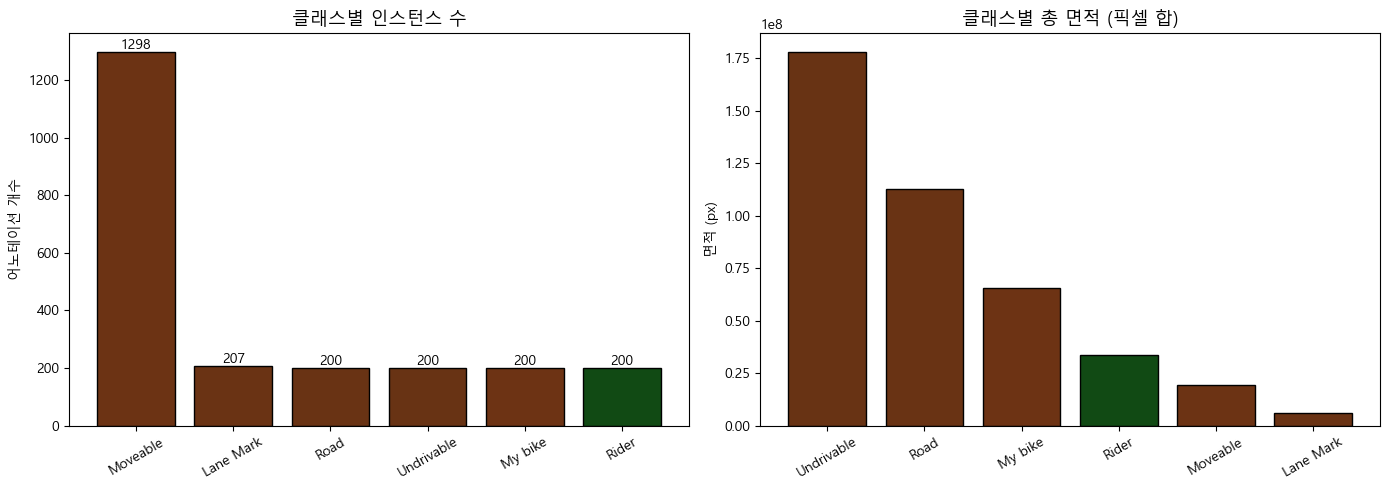

저장: eda_class_distribution.png


In [23]:
# 시각화: 클래스 분포 + 면적 비율
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [id2color[c['id']] for c in coco['categories']]
name_color = {c['name']: id2color[c['id']] for c in coco['categories']}

bar_colors = [name_color[n] for n in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('클래스별 인스턴스 수', fontsize=13)
axes[0].set_ylabel('어노테이션 개수')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# 면적 합 기준
area_sum = ann_df.groupby('category_name')['area'].sum().sort_values(ascending=False)
bar_colors2 = [name_color[n] for n in area_sum.index]
axes[1].bar(area_sum.index, area_sum.values, color=bar_colors2, edgecolor='black')
axes[1].set_title('클래스별 총 면적 (픽셀 합)', fontsize=13)
axes[1].set_ylabel('면적 (px)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: eda_class_distribution.png')

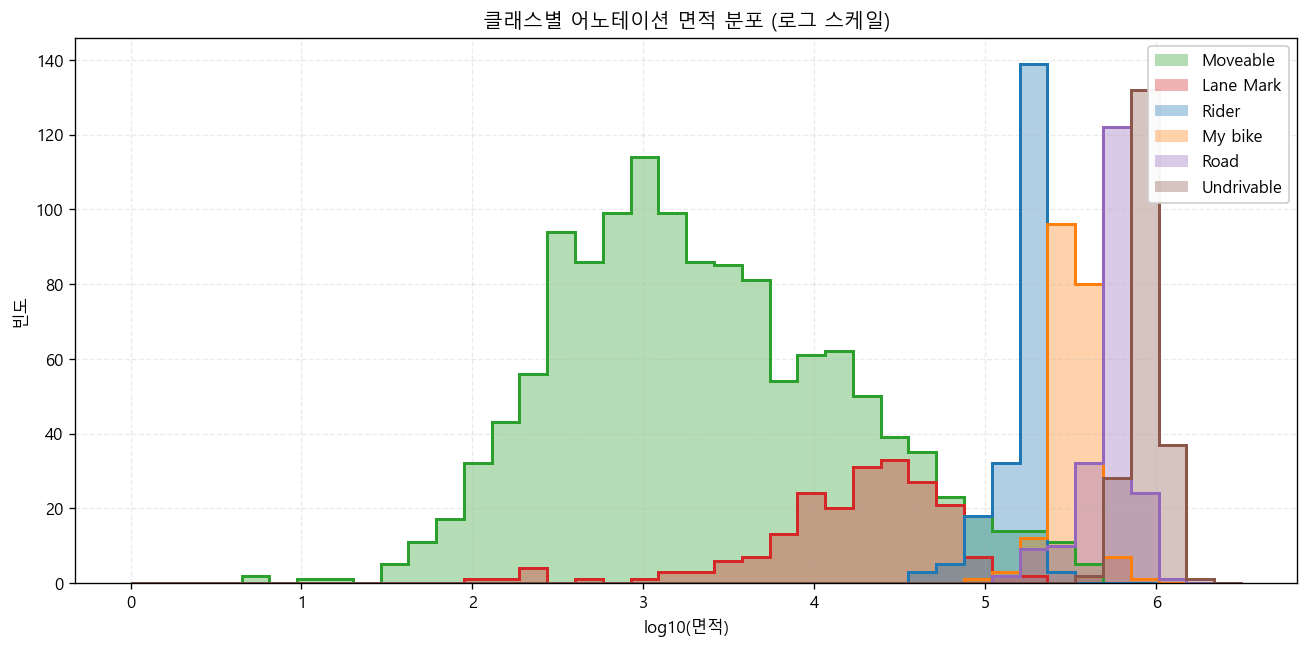

In [24]:
# 어노테이션 면적 분포 (로그 스케일)
# 주의: name_color (JSON 원본 팔레트) 는 6개 클래스가 거의 같은 갈색이라 구분 불가
# tab10 팔레트로 교체해서 6개 클래스를 명확히 구분
class_names = [c['name'] for c in coco['categories']]
palette = plt.get_cmap('tab10').colors
distinct_color = {n: palette[i % 10] for i, n in enumerate(class_names)}

fig, ax = plt.subplots(figsize=(11, 5.5))

# 면적 중앙값 오름차순 정렬 → 큰 영역 클래스가 앞을 가리지 않도록
groups = sorted(
    ann_df.groupby('category_name'),
    key=lambda kv: np.median(np.log10(kv[1]['area'] + 1)),
)

bins = np.linspace(0, 6.5, 41)
for name, grp in groups:
    logs = np.log10(grp['area'] + 1)
    c = distinct_color[name]
    ax.hist(logs, bins=bins, alpha=0.35, color=c, label=name)
    ax.hist(logs, bins=bins, histtype='step', color=c, linewidth=1.8)

ax.set_xlabel('log10(면적)')
ax.set_ylabel('빈도')
ax.set_title('클래스별 어노테이션 면적 분포 (로그 스케일)')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('eda_area_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


        n_objects   n_classes
count  200.000000  200.000000
mean    11.525000    5.935000
std      4.504534    0.247144
min      5.000000    5.000000
25%      8.000000    6.000000
50%     11.000000    6.000000
75%     14.000000    6.000000
max     26.000000    6.000000


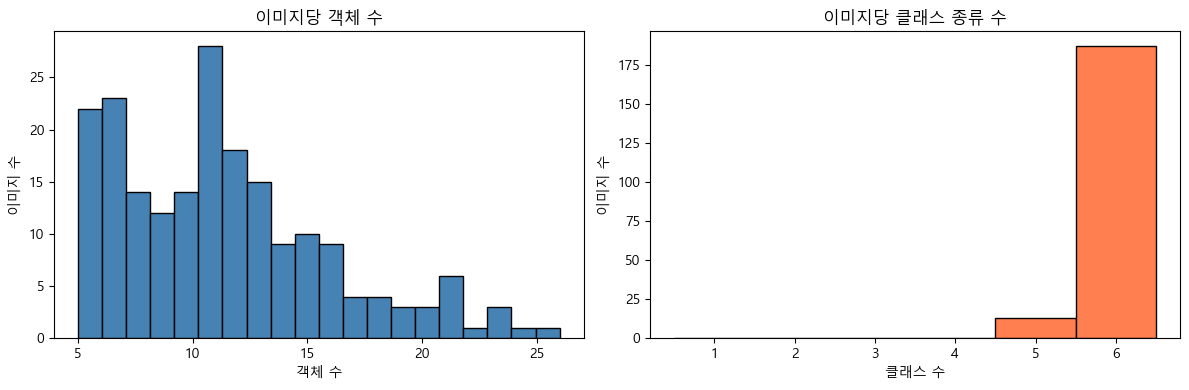

In [25]:
# 이미지당 객체 수 + 클래스 다양성
per_image = ann_df.groupby('image_id').agg(
    n_objects=('id', 'count'),
    n_classes=('category_id', 'nunique')
)
print(per_image.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_image['n_objects'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('이미지당 객체 수')
axes[0].set_xlabel('객체 수'); axes[0].set_ylabel('이미지 수')
axes[1].hist(per_image['n_classes'], bins=range(1, 8), color='coral', edgecolor='black', align='left')
axes[1].set_title('이미지당 클래스 종류 수')
axes[1].set_xlabel('클래스 수'); axes[1].set_ylabel('이미지 수')
plt.tight_layout()
plt.savefig('eda_per_image.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 야간 조도 분석

야간 데이터셋이라 일반적인 모델이 잘 작동할지 확인이 필요. 이미지 밝기 분포를 보자.

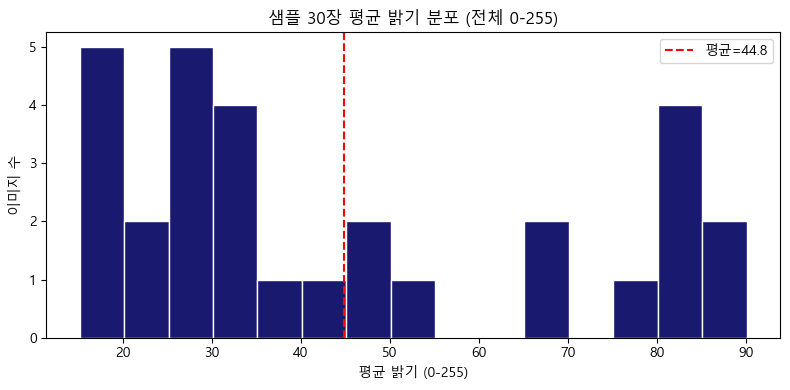

평균 밝기: 44.8 / 255 → 야간임을 확인


In [26]:
import random
random.seed(42)

# 매칭된 이미지 중 30장 샘플링하여 평균 밝기 측정
matched_imgs = [img for img in coco['images'] if img['file_name'] in actual_files]
sample = random.sample(matched_imgs, min(30, len(matched_imgs)))

brightnesses = []
for img_meta in sample:
    img = Image.open(IMG_DIR / img_meta['file_name']).convert('L')
    arr = np.array(img)
    brightnesses.append(arr.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(brightnesses, bins=15, color='midnightblue', edgecolor='white')
ax.axvline(np.mean(brightnesses), color='red', linestyle='--', label=f'평균={np.mean(brightnesses):.1f}')
ax.set_xlabel('평균 밝기 (0-255)')
ax.set_ylabel('이미지 수')
ax.set_title(f'샘플 {len(sample)}장 평균 밝기 분포 (전체 0-255)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_brightness.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'평균 밝기: {np.mean(brightnesses):.1f} / 255 → 야간임을 확인')

## 7. 샘플 이미지 + 세그멘테이션 마스크 시각화

COCO segmentation은 polygon 형태. 직접 그려서 확인.

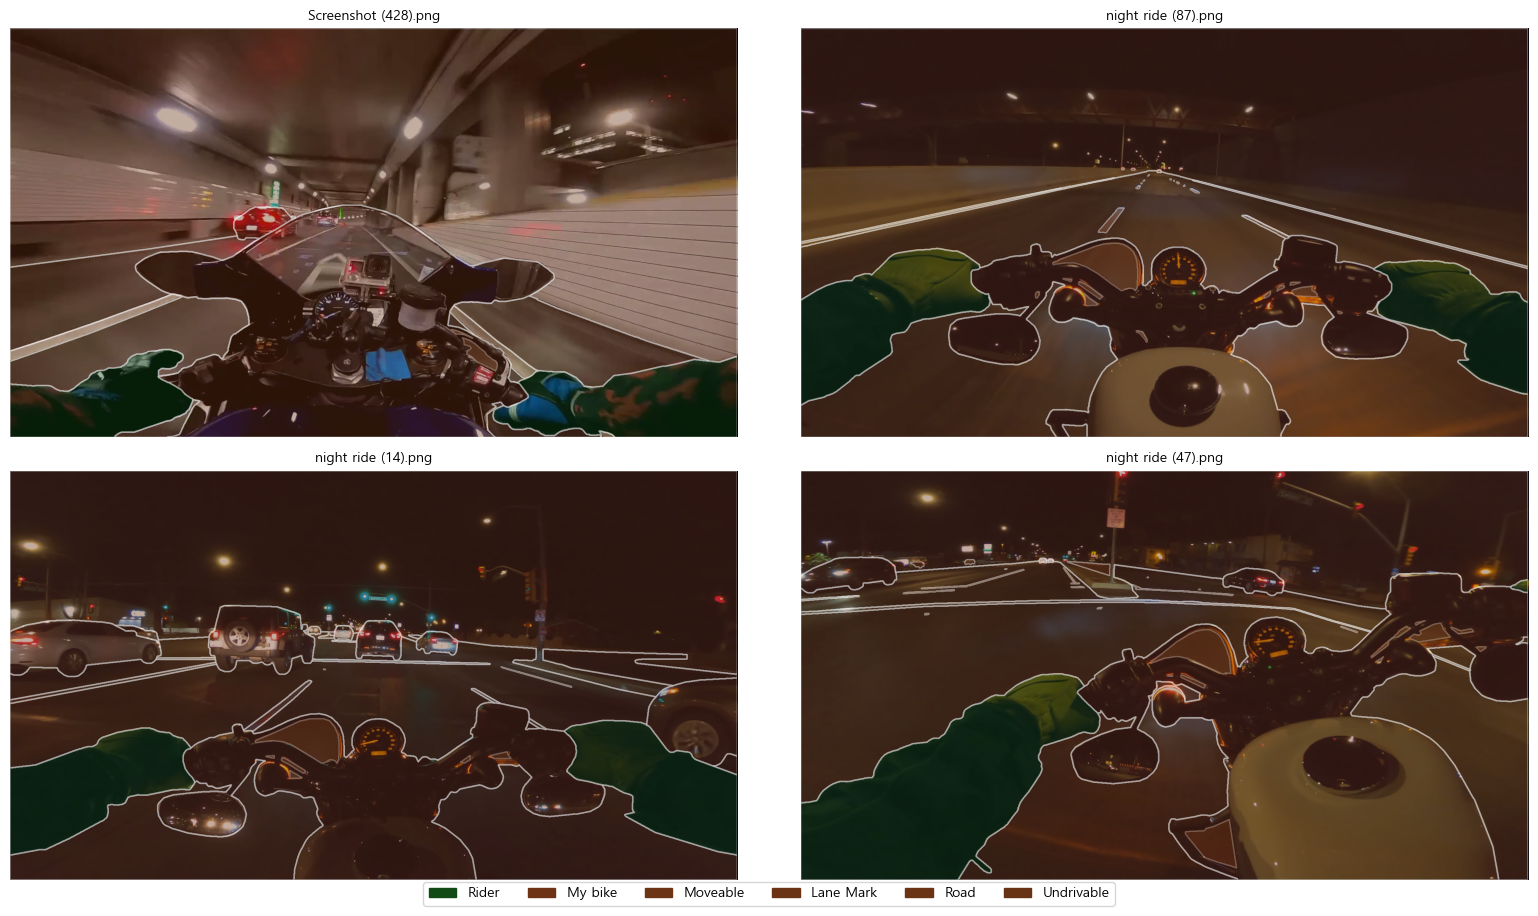

In [27]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def draw_annotations(img_meta, anns, ax):
    img = Image.open(IMG_DIR / img_meta['file_name']).convert('RGB')
    ax.imshow(img)
    
    patches_list = []
    colors_list = []
    for ann in anns:
        seg = ann['segmentation']
        # COCO polygon: list of [x1,y1,x2,y2,...]
        if isinstance(seg, list):
            for poly in seg:
                pts = np.array(poly).reshape(-1, 2)
                patches_list.append(Polygon(pts, closed=True))
                colors_list.append(id2color[ann['category_id']])
    
    pc = PatchCollection(patches_list, alpha=0.4, facecolors=colors_list, edgecolors='white', linewidths=1)
    ax.add_collection(pc)
    ax.set_title(img_meta['file_name'], fontsize=10)
    ax.axis('off')

# 매칭된 이미지 중 객체 수 적당한 4장 선택
img_to_anns = defaultdict(list)
for ann in coco['annotations']:
    img_to_anns[ann['image_id']].append(ann)

candidates = [img for img in matched_imgs if 5 <= len(img_to_anns[img['id']]) <= 15]
samples = random.sample(candidates, min(4, len(candidates)))

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, img_meta in zip(axes.flatten(), samples):
    draw_annotations(img_meta, img_to_anns[img_meta['id']], ax)

# 범례 (한 번만)
legend_handles = [patches.Patch(color=id2color[c['id']], label=c['name']) for c in coco['categories']]
fig.legend(handles=legend_handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('eda_sample_masks.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. fuse/save 파일 비교

원본 / Superannotate fuse / Superannotate save 파일을 나란히 비교.

원본+fuse+save 모두 있는 파일: 93개


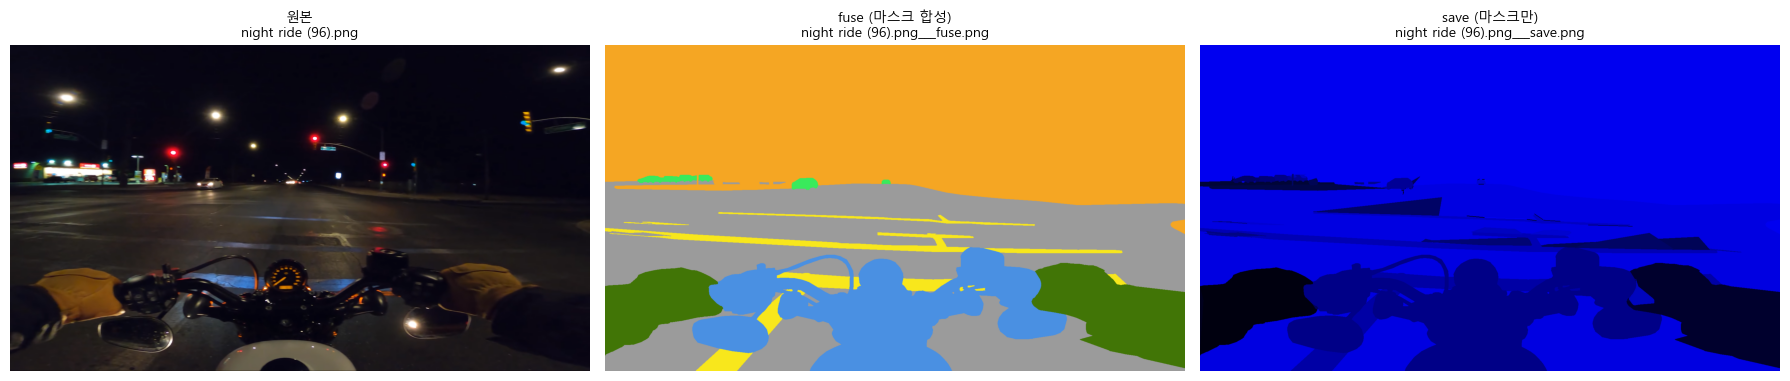

In [28]:
# fuse/save가 모두 있는 night ride 파일 찾기
samples_with_viz = []
for f in night_ride_orig:
    fuse = IMG_DIR / f'{f.name}___fuse.png'
    save = IMG_DIR / f'{f.name}___save.png'
    if fuse.exists() and save.exists():
        samples_with_viz.append((f, fuse, save))

print(f'원본+fuse+save 모두 있는 파일: {len(samples_with_viz)}개')

if samples_with_viz:
    sample = random.choice(samples_with_viz)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['원본', 'fuse (마스크 합성)', 'save (마스크만)']
    for ax, p, t in zip(axes, sample, titles):
        ax.imshow(Image.open(p))
        ax.set_title(f'{t}\n{p.name}', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('eda_fuse_save_compare.png', dpi=120, bbox_inches='tight')
    plt.show()

## 9. JSON 포맷 특이사항 (Superannotate 특유)

파일명에 `(pixel)`이 들어있고 크기가 **306MB**인 건 이유가 있음. 표준 COCO와 다른 특징들이 있어서 학습 전에 짚고 가야 함.

- **segmentation이 "픽셀 단위 외곽선"으로 저장됨**: polygon 근사가 아니라 외곽을 1픽셀씩 찍은 구조 → vertex가 수천~수만 개
- **category ID가 Superannotate 내부 ID**: `1323880~1329681` → 학습용으로 `0~6` remapping 필요
- **category color가 거의 동일**: 5개 클래스 G/B값이 같고 R값만 1~5 차이 → 시각화용 팔레트 별도 필요

아래 셀들에서 이 내용을 정량적으로 확인.

In [29]:
# segmentation 형식 + polygon vertex 수 통계
seg_formats = Counter()
poly_vertex_counts = []

for ann in coco['annotations']:
    s = ann['segmentation']
    if isinstance(s, list):
        if s and isinstance(s[0], list):
            seg_formats['list[polygon]'] += 1
            for poly in s:
                poly_vertex_counts.append(len(poly) // 2)  # (x,y) 쌍 개수
        else:
            seg_formats['list[other]'] += 1
    elif isinstance(s, dict):
        seg_formats['dict(RLE)'] += 1

print('segmentation 형식 분포:')
for k, v in seg_formats.items():
    print(f'  {k}: {v}개 ({v/len(coco["annotations"])*100:.1f}%)')

print(f'\npolygon vertex 수 통계 (총 {len(poly_vertex_counts):,}개 polygon):')
print(f'  평균:   {np.mean(poly_vertex_counts):,.0f} vertex')
print(f'  중앙값: {np.median(poly_vertex_counts):,.0f}')
print(f'  최소:   {min(poly_vertex_counts):,}')
print(f'  최대:   {max(poly_vertex_counts):,}')
print(f'\n참고: 일반 COCO polygon은 객체당 10~50 vertex 수준')
print(f'     → 이 데이터셋은 외곽선을 픽셀 단위로 전부 찍음 (파일명 "(pixel)"의 의미)')
print(f'     → 파일 크기 306MB의 원인')

segmentation 형식 분포:
  list[polygon]: 2305개 (100.0%)

polygon vertex 수 통계 (총 8,392개 polygon):
  평균:   756 vertex
  중앙값: 166
  최소:   3
  최대:   13,008

참고: 일반 COCO polygon은 객체당 10~50 vertex 수준
     → 이 데이터셋은 외곽선을 픽셀 단위로 전부 찍음 (파일명 "(pixel)"의 의미)
     → 파일 크기 306MB의 원인


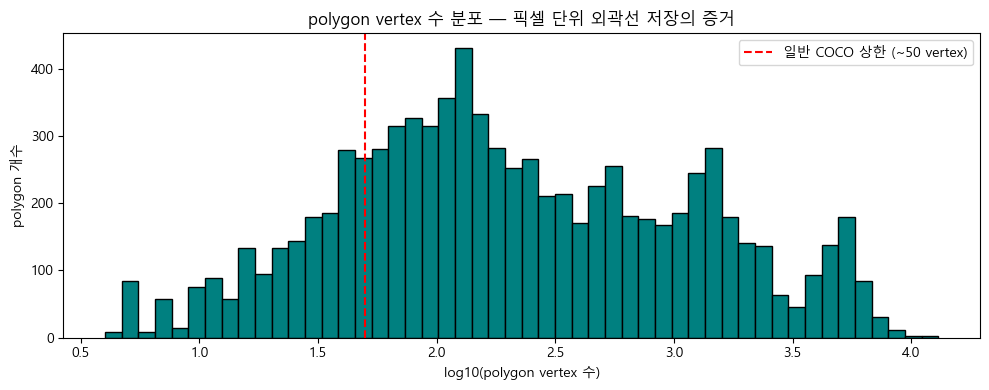

In [30]:
# polygon vertex 수 분포 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(np.array(poly_vertex_counts) + 1), bins=50, color='teal', edgecolor='black')
ax.axvline(np.log10(50), color='red', linestyle='--', label='일반 COCO 상한 (~50 vertex)')
ax.set_xlabel('log10(polygon vertex 수)')
ax.set_ylabel('polygon 개수')
ax.set_title('polygon vertex 수 분포 — 픽셀 단위 외곽선 저장의 증거')
ax.legend()
plt.tight_layout()
plt.savefig('eda_polygon_vertex_dist.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.1 카테고리 ID + 색상 이슈

- **카테고리 ID가 비표준**: Superannotate 내부 ID (`1323880~1329681`)를 그대로 남김 → 학습 시 `0~6`으로 remapping 필요
- **카테고리 color가 거의 동일**: 5개 클래스가 `G=51, B=20`으로 동일하고 R값만 1~5 차이 → `___save.png` 마스크를 육안으로 볼 때 구분 거의 불가능. 시각화 전용 팔레트 별도 정의 필요.

=== 원본 카테고리 ID + color ===
  Rider        → id=1329681, color=[17, 74, 20]
  My bike      → id=1323885, color=[109, 51, 20]
  Moveable     → id=1323884, color=[108, 51, 20]
  Lane Mark    → id=1323882, color=[106, 51, 20]
  Road         → id=1323881, color=[105, 51, 20]
  Undrivable   → id=1323880, color=[104, 51, 20]

=== 학습용 remapping (0=background) ===
  label=1: Undrivable   (원본 id=1323880)
  label=2: Road         (원본 id=1323881)
  label=3: Lane Mark    (원본 id=1323882)
  label=4: Moveable     (원본 id=1323884)
  label=5: My bike      (원본 id=1323885)
  label=6: Rider        (원본 id=1329681)


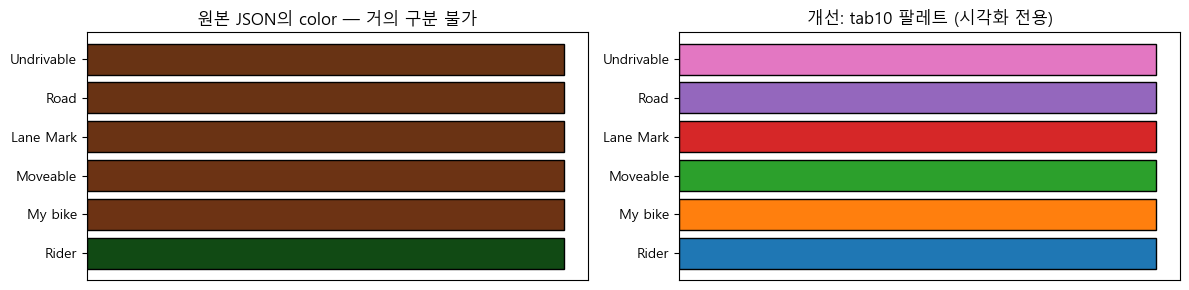

In [31]:
# 카테고리 ID + 원본 color 확인
print('=== 원본 카테고리 ID + color ===')
for c in coco['categories']:
    print(f'  {c["name"]:12} → id={c["id"]}, color={c["color"]}')

# 학습용 label remapping (0 = background)
cat_id_to_label = {
    1323880: 1,  # Undrivable
    1323881: 2,  # Road
    1323882: 3,  # Lane Mark
    1323884: 4,  # Moveable
    1323885: 5,  # My bike
    1329681: 6,  # Rider
}
print('\n=== 학습용 remapping (0=background) ===')
for cid, label in cat_id_to_label.items():
    print(f'  label={label}: {id2name[cid]:12} (원본 id={cid})')

# 원본 color vs 개선 팔레트 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
names = [c['name'] for c in coco['categories']]
orig_colors = [id2color[c['id']] for c in coco['categories']]

axes[0].barh(names, [1]*len(names), color=orig_colors, edgecolor='black')
axes[0].set_title('원본 JSON의 color — 거의 구분 불가')
axes[0].set_xticks([])

improved = plt.cm.tab10(np.linspace(0, 0.6, len(names)))
axes[1].barh(names, [1]*len(names), color=improved, edgecolor='black')
axes[1].set_title('개선: tab10 팔레트 (시각화 전용)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('eda_color_palette_compare.png', dpi=120, bbox_inches='tight')
plt.show()

### 9.2 학습 전 전처리 action items

이 JSON 포맷 특성 때문에 학습 전에 반드시 해야 할 것들:

1. **Polygon → raster mask 변환**: 수천 vertex polygon을 매 epoch마다 렌더링하면 느림. 한 번 `.png` 마스크로 저장해서 재사용.
   ```python
   import cv2
   mask = np.zeros((H, W), dtype=np.uint8)
   cv2.fillPoly(mask, [pts.astype(np.int32)], label_id)
   ```
2. **category_id remapping**: 위 `cat_id_to_label` dict 사용 → 0~6 label로 변환
3. **시각화용 색상 팔레트 재정의**: JSON의 `color` 필드 대신 `tab10` 등 구분 잘 되는 팔레트 사용
4. **Undrivable의 이질성 주의**: 첫 어노테이션 bbox가 `[0, 0, 1920, 551]` (화면 상단 절반) — 하늘/건물 다 섞여있음. 위험도 계산 시 "진짜 장애물"과 "단순 배경" 구분 불가능함을 기억.

→ 이 전처리 단계는 별도 학습 노트북 첫 부분에서 처리.

## 10. EDA 요약 + 다음 단계

### 발견 사항
- **데이터 규모**: 200장 라벨 / 6 클래스 / 2,305 어노테이션 → 소규모. 사전학습 모델 fine-tuning 필수
- **해상도**: 1920×1080 → 학습 시 다운샘플 권장 (예: 512×288 또는 768×432)
- **클래스 불균형**: 픽셀 면적 기준 Road/Undrivable이 지배적, Lane Mark/Moveable이 소수. 단 "작은 클래스"라도 학습 난이도는 다름:
  - **어렵고 중요**: Moveable (변동 큼, 위험도 핵심), Lane Mark (얇고 길어 면적 최소)
  - **쉬움**: Rider/My bike (위치·형태 고정) — 오히려 기준점 역할이라 위험도 계산에서 제외할 영역
  - → 베이스라인은 균등 가중치로 돌려 클래스별 IoU 확인 후 선택적 가중치 부여
- **야간 조도**: 평균 밝기 낮음. **도메인 갭**(ImageNet/주간 → 야간) + **환경 다양성**(도심/시골/가로등/안개) 두 차원 존재 → fine-tuning + augmentation 두 축으로 대응
- **fuse/save 파일**: 학습엔 불필요 (JSON polygon으로 마스크 생성 가능). 시각화 자료로 활용
- **JSON 포맷 (섹션 9)**: Superannotate 특유 "픽셀 단위 외곽선" + 비표준 category ID + 구분 안 되는 color → 학습 전 raster mask 변환 + ID remapping + 팔레트 교체 필수

### 위험도 히트맵 설계 가설
- **위험 클래스 가중치**: Moveable(차량) > Lane Mark(경계) > Undrivable(경계) > Road (기준)
- **Rider/My bike는 "자기 참조"**: 히트맵에서 제외하거나 낮은 가중치
- **거리 가중치**: Depth Anything V2의 inverse depth → 가까울수록 높은 위험
- **위치 가중치**: 화면 중앙·하단(라이더 진행 방향)에 가까울수록 높은 위험
- **fusion**: `risk = class_weight × inv_depth × position_weight` → Gaussian smoothing

### 다음 노트북 (계획)
- `02_baseline_segmentation.ipynb`: polygon → raster mask 변환 + SegFormer-B0 fine-tuning, 클래스별 IoU + mIoU 측정
- `03_depth_estimation.ipynb`: Depth Anything V2 zero-shot inference
- `04_risk_heatmap.ipynb`: 세그+깊이 fusion → 위험도 히트맵
- `05_experiments.ipynb`: 모델/aug/가중치 비교

### 팀 논의 필요 사항
- 위험도 정의 합의 (어떤 상황을 "위험"으로 볼지)
- 평가 지표: 세그(mIoU)는 명확, 위험도는 정성평가 + 케이스 스터디로?
- 작업 분담 (세그 / 깊이 / fusion / 발표)